In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# 添加项目根目录到路径
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from env.cellfree.env import CellFreeEnv
from model.sac.sac import Actor
from env.cellfree.config import M, N, GATE_K, GATE_TH

In [2]:
# 配置参数
RUN_NAME = 'Dec04-002517'  # 您的运行ID
ALGORITHM = 'sac'
ENV_NAME = 'cellfree'
MODEL_PATH = f'../log/combined/{ALGORITHM}/{ENV_NAME}/{RUN_NAME}/finetune_policy.pth'

print(f"Loading model from: {MODEL_PATH}")

Loading model from: ../log/combined/sac/cellfree/Dec04-002517/finetune_policy.pth


In [3]:
# 初始化环境和模型
env = CellFreeEnv()
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

# 注意：必须与训练时的 hidden_dim 一致
actor = Actor(state_dim, action_dim, hidden_dim=256)

# 加载权重
if os.path.exists(MODEL_PATH):
    # 加载整个 checkpoint (Tianshou 保存的是 policy state_dict)
    ckpt = torch.load(MODEL_PATH, map_location='cpu')
    
    # 尝试提取 actor 的权重
    # Tianshou 的 SAC policy state_dict 包含 'actor', 'actor_optim', 'critic1', etc.
    # 我们需要过滤出 actor 的部分
    actor_state_dict = {k.replace('actor.', ''): v for k, v in ckpt.items() if k.startswith('actor.')}
    
    if actor_state_dict:
        actor.load_state_dict(actor_state_dict)
        print("Loaded actor weights from policy state dict.")
    elif 'model' in ckpt:
        actor.load_state_dict(ckpt['model'], strict=False)
        print("Loaded from 'model' key.")
    else:
        # 尝试直接加载
        try:
            actor.load_state_dict(ckpt, strict=False)
            print("Loaded policy state dict directly.")
        except Exception as e:
            print(f"Warning: Could not load weights directly: {e}")
            print("Keys available:", ckpt.keys())
            
actor.eval()

Loaded policy state dict directly.


Actor(
  (embedding): Linear(in_features=13, out_features=128, bias=True)
  (attention1): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (attention2): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (net): Sequential(
    (0): Linear(in_features=640, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
  )
  (mean_linear): Linear(in_features=256, out_features=25, bias=True)
  (log_std_linear): Linear(in_features=256, out_features=25, bias=True)
)

## 1. 权重分布分析
查看每一层的权重直方图。如果权重集中在 0 附近且方差极小，可能发生了梯度消失。如果权重非常大，可能不稳定。

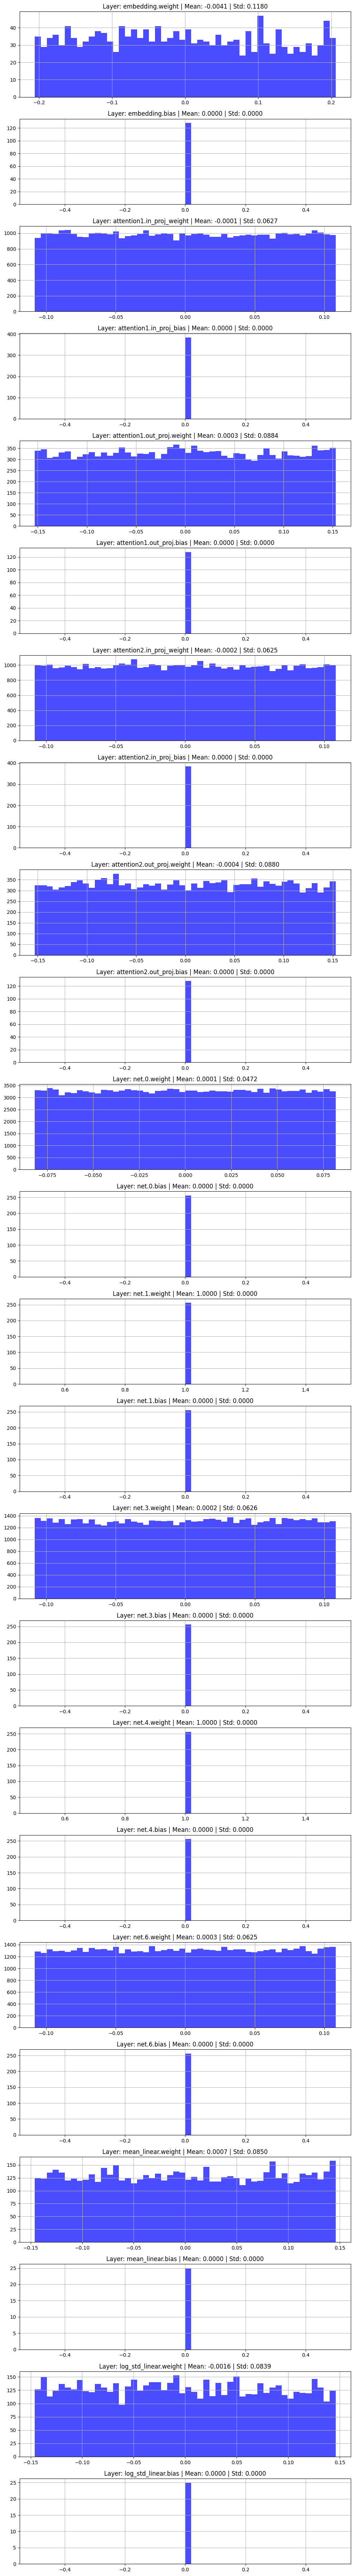

In [4]:
def plot_weights(model):
    params = list(model.named_parameters())
    fig, axes = plt.subplots(len(params), 1, figsize=(10, 3*len(params)))
    if len(params) == 1:
        axes = [axes]
    
    for i, (name, param) in enumerate(params):
        data = param.data.cpu().numpy().flatten()
        ax = axes[i]
        ax.hist(data, bins=50, alpha=0.7, color='blue')
        ax.set_title(f'Layer: {name} | Mean: {data.mean():.4f} | Std: {data.std():.4f}')
        ax.grid(True)
        
    plt.tight_layout()
    plt.show()

plot_weights(actor)

## 2. 动作输出分布分析
输入一批随机状态，观察模型输出的原始动作（Raw Action）和经过 Soft Gate 后的有效功率（Effective Power）。
如果有效功率大部分是 0 或 1，说明稀疏性学习得很好。如果都在 0.5 附近，说明模型很困惑。

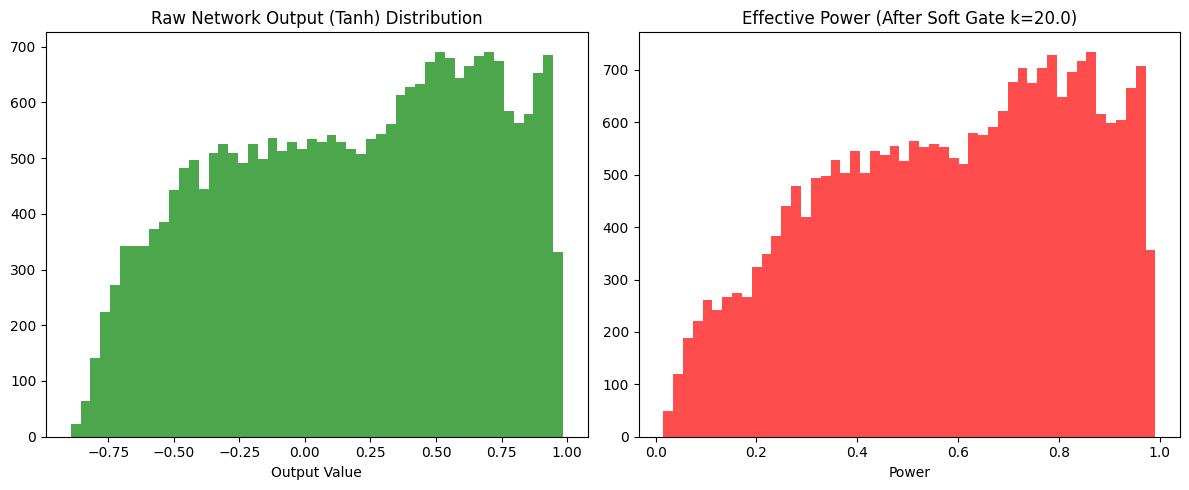

In [5]:
# 生成随机状态 Batch
BATCH_SIZE = 1000
states = []
for _ in range(BATCH_SIZE):
    s, _ = env.reset()
    states.append(s)
states = torch.tensor(np.array(states), dtype=torch.float32)

# 推理
with torch.no_grad():
    # SAC Actor forward 返回 (logits, hidden)
    # 注意：根据 sac.py 的实现，forward 返回的是 logits
    # 然后通常接 tanh 和缩放。我们需要确认 sac.py 的实现细节。
    # 假设 actor(state) 返回的是 (logits, state)
    result = actor(states)
    if isinstance(result, tuple):
        logits = result[0]
    else:
        logits = result
        
    # 假设 logits 经过 tanh 才是 action
    # 如果 sac.py 中已经包含了 tanh，则 logits 就是 action
    # 通常 SAC 输出是均值和标准差，这里我们只看均值（确定性策略）
    raw_actions = torch.tanh(logits).numpy().flatten()
    
    # 如果模型输出已经是 [0,1] (Sigmoid)，则不需要 tanh
    # 让我们先假设是 [-1, 1] 的 tanh 输出，然后映射到 [0, 1] (如果是功率)
    # 但在这个项目中，动作空间通常是 [0, 1] 或者是 [-1, 1]
    # 让我们看下 env.action_space
    # 如果 action_space 是 Box(-1, 1)，则 raw_actions 是 [-1, 1]
    # 如果是 Box(0, 1)，则可能是 sigmoid
    
    # 简单起见，我们直接看 raw_actions 的分布

# 绘制原始动作分布
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(raw_actions, bins=50, color='green', alpha=0.7)
plt.title(f'Raw Network Output (Tanh) Distribution')
plt.xlabel('Output Value')

# 应用 Soft Gate
# 假设动作被映射到 [0, 1] 用于功率
# 如果 raw 是 [-1, 1]，我们需要 (raw + 1) / 2
power_actions = (raw_actions + 1) / 2

gate = 1.0 / (1.0 + np.exp(-GATE_K * (power_actions - GATE_TH)))
effective_power = power_actions * gate

plt.subplot(1, 2, 2)
plt.hist(effective_power, bins=50, color='red', alpha=0.7)
plt.title(f'Effective Power (After Soft Gate k={GATE_K})')
plt.xlabel('Power')

plt.tight_layout()
plt.show()